In [10]:
PATH_TO_RESULTS_FOLDER = (
    ".result/13-lens-simulation-after-classical-numerics/2025-12-08_11-49-44/"
)
# PATH_TO_RESULTS_FILE = PATH_TO_RESULTS_FOLDER + "result.npz"
# PATH_TO_INITIAL_PARAMETERS_FILE = PATH_TO_RESULTS_FOLDER + "initial_parameters.json"

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from qiskit_signals.quantum_axis import EncodingType, PositionAxis
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.storage import load_initial_parameters, load_numpy_results
from wave_optics_propagation.visualization import plot_wavefunction

In [12]:
snapshots = load_numpy_results(PATH_TO_RESULTS_FOLDER)
initial_parameters = load_initial_parameters(PATH_TO_RESULTS_FOLDER)

In [13]:
# beam parameters
vacuum_wavelength = initial_parameters["vacuum_wavelength"]
beam_FWHM = initial_parameters["beam_FWHM"]

# lens parameters
focal_length = initial_parameters["focal_length"]
lens_diameter = initial_parameters["lens_diameter"]
refractive_index = initial_parameters["refractive_index"]
lens_thickness = initial_parameters["lens_thickness"]

# free space propagation parameters
propagation_after_lens = initial_parameters["propagation_after_lens"]

# simulation parameters
transverse_length = initial_parameters["transverse_length"]
num_of_steps_after_lens = initial_parameters["num_of_steps_after_lens"]
lens_slices = initial_parameters["lens_slices"]
num_qubits = initial_parameters["num_qubits"]
max_delta = initial_parameters["max_delta"]

# simulation calculated parameters
total_lenses_simulated = initial_parameters["total_lenses_simulated"]

In [14]:
radius_of_curvature = focal_length * (refractive_index - 1)
k_0 = 2 * constants.pi / vacuum_wavelength
reduced_wavelength = vacuum_wavelength / refractive_index

dimension = 2**num_qubits
delta_x = transverse_length / dimension

gaussian_mean = transverse_length / 2
gaussian_beam_waist = beam_FWHM / np.sqrt(2 * np.log(2))
# gaussian_sigma = gaussian_beam_waist / np.sqrt(2)

# vacuum_rayleigh_length = (np.pi * gaussian_beam_waist**2) / vacuum_wavelength

lens_slice_thickness = lens_thickness / lens_slices
step_size_after_lens = propagation_after_lens / num_of_steps_after_lens

x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)

In [15]:
# def process_statevector(statevector):
#     return statevector
def process_statevector(statevector):
    """Process the statevector to extract position probabilities."""
    # n = statevector.num_qubits
    # rho = partial_trace(statevector, np.arange(int(n // 2), n).tolist())
    # reduced_state = rho.to_statevector()

    # return reduced_state
    return statevector


initial_statevector = process_statevector(snapshots[f"step_{0}"])

lens_statevectors = [
    process_statevector(snapshots[f"step_lens_{i}"])
    if f"step_lens_{i}" in snapshots
    else None
    for i in range(lens_slices)
]
after_lens_statevectors = [
    process_statevector(snapshots[f"step_after_lens_{i + 1}"])
    if f"step_after_lens_{i + 1}" in snapshots
    else None
    for i in range(num_of_steps_after_lens)
]

Plotting initial state


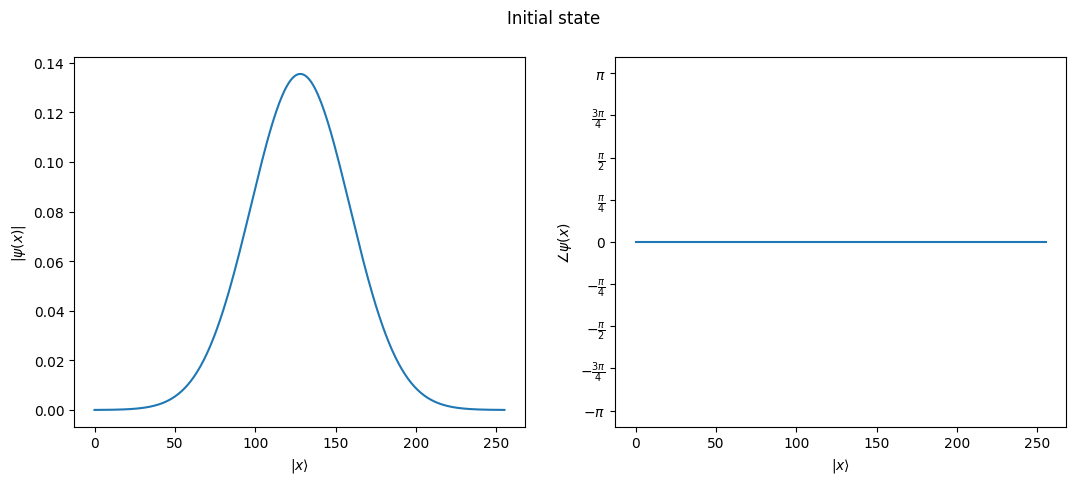

Plotting lens slice 1/100


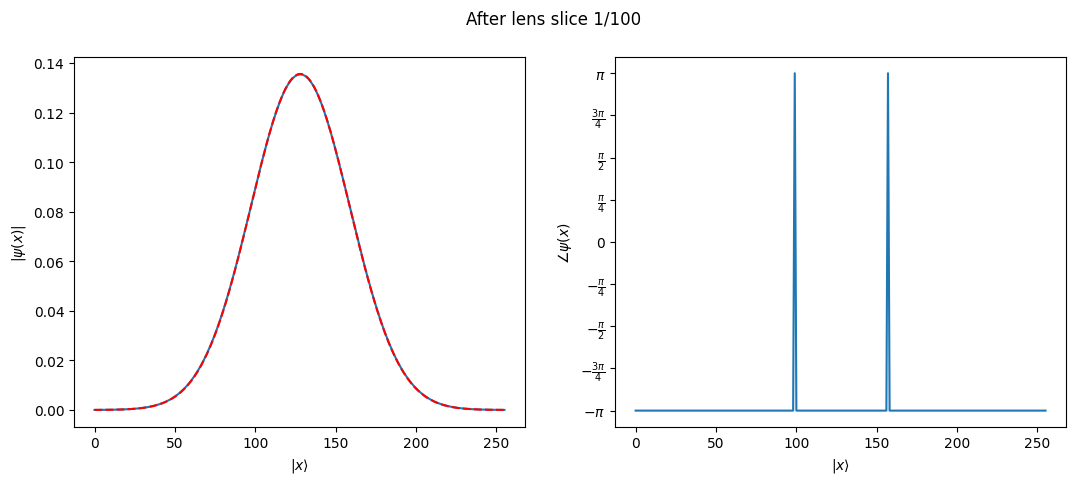

Plotting lens slice 11/100


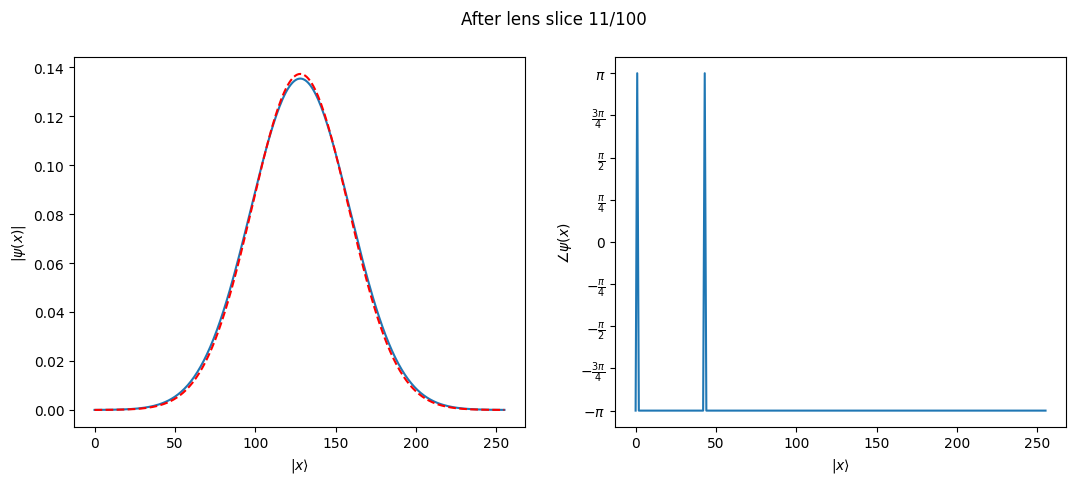

Plotting lens slice 21/100


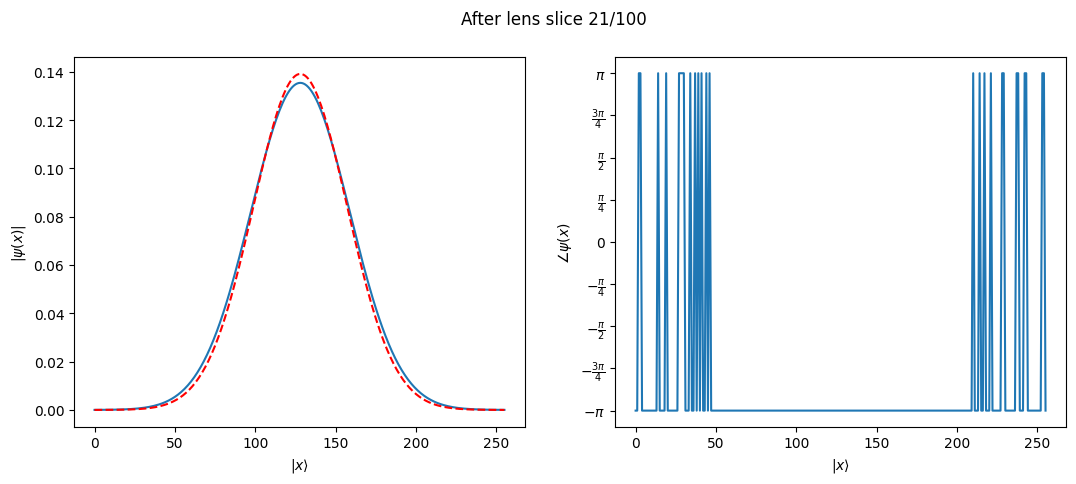

Plotting lens slice 31/100


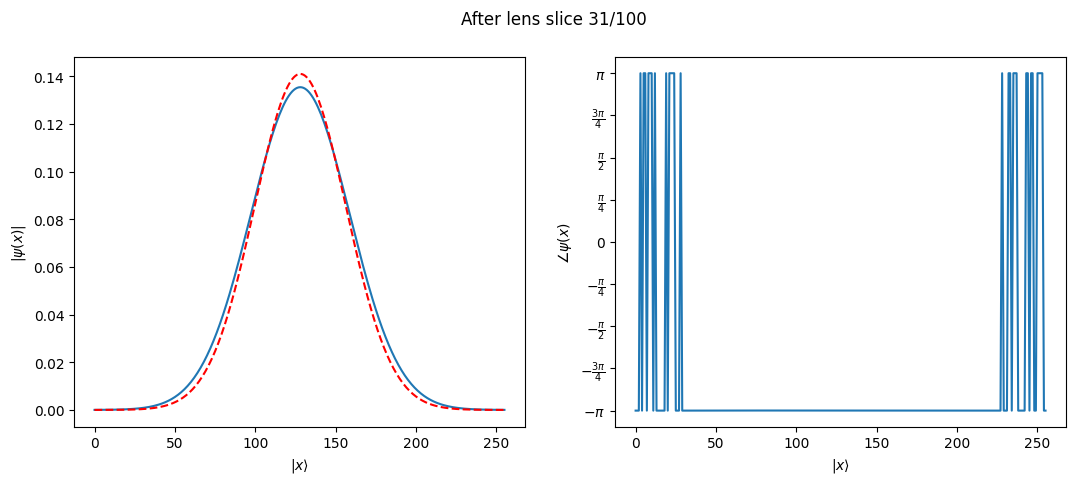

Plotting lens slice 41/100


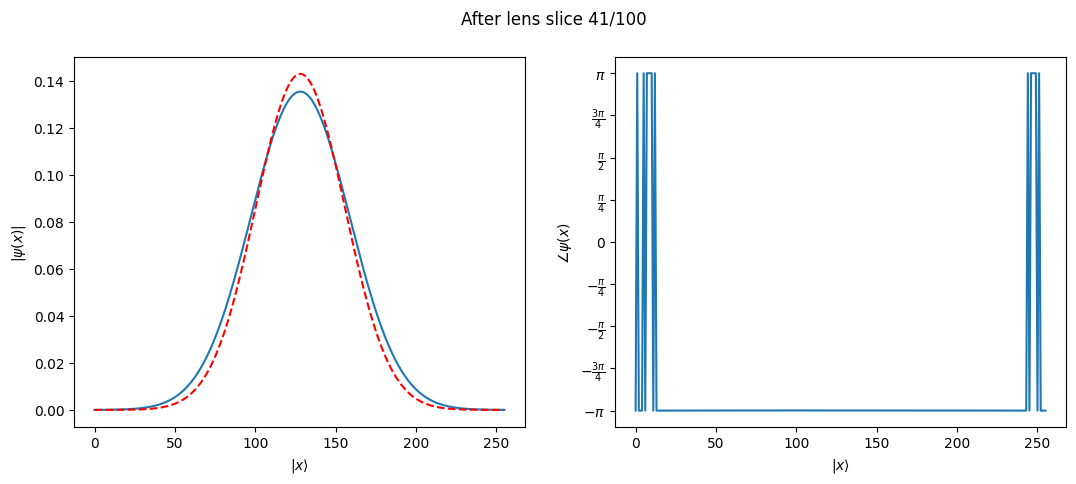

Plotting lens slice 51/100


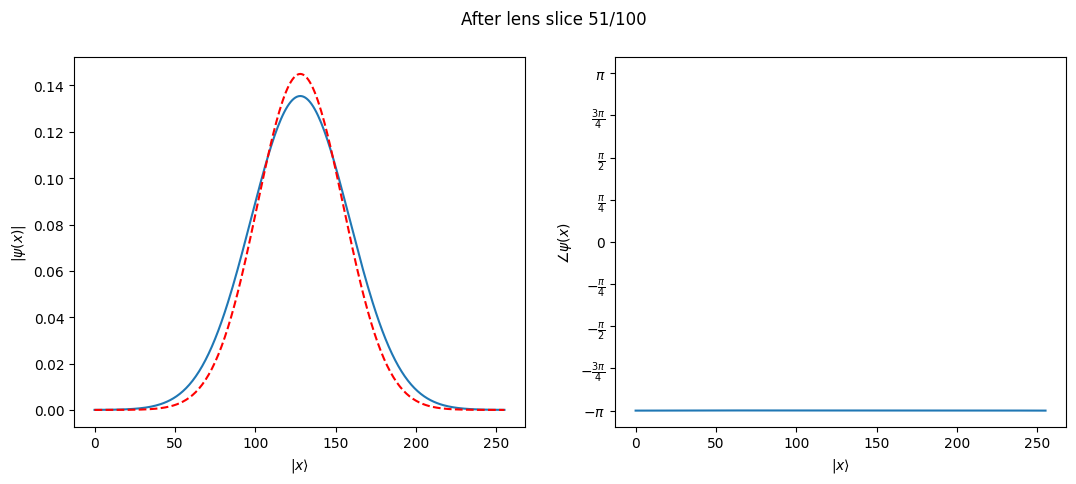

Plotting lens slice 61/100


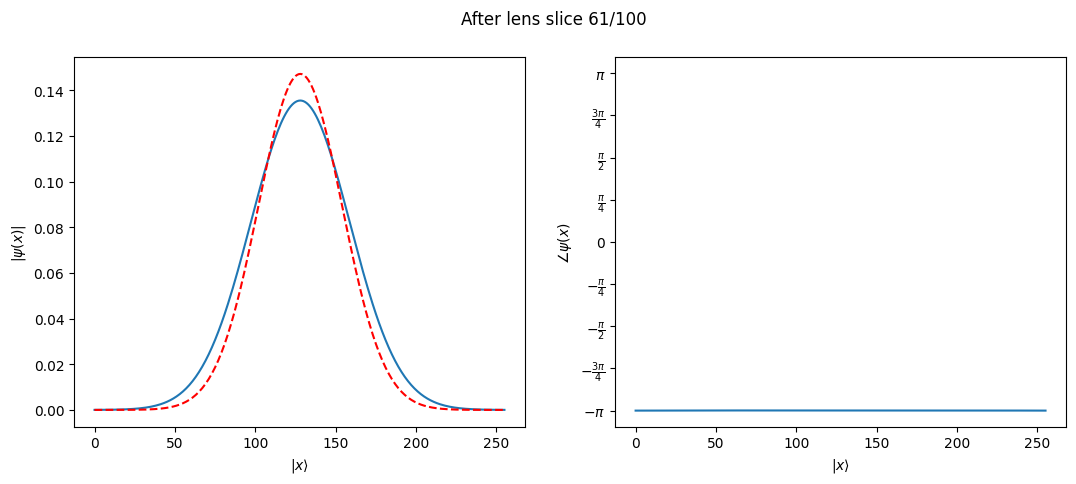

Plotting lens slice 71/100


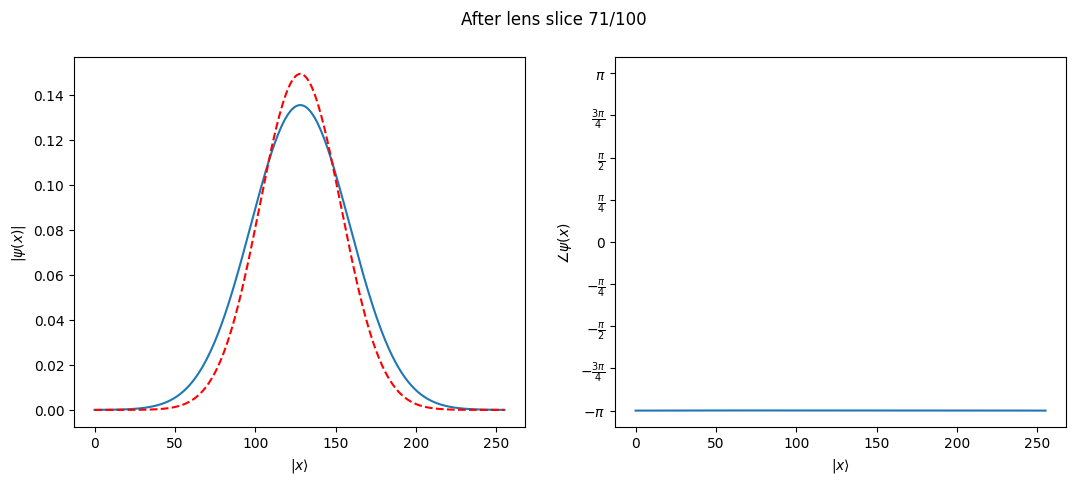

Plotting lens slice 81/100


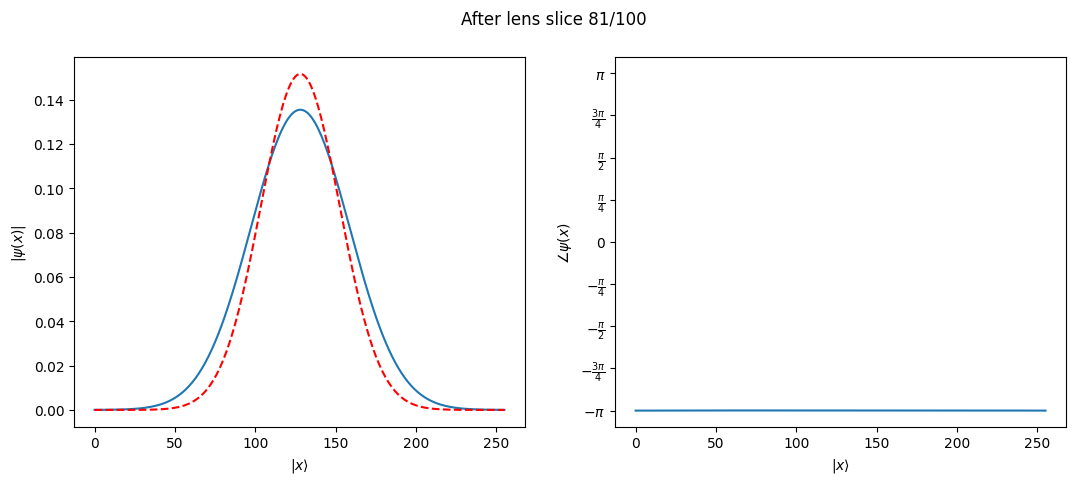

Plotting lens slice 91/100


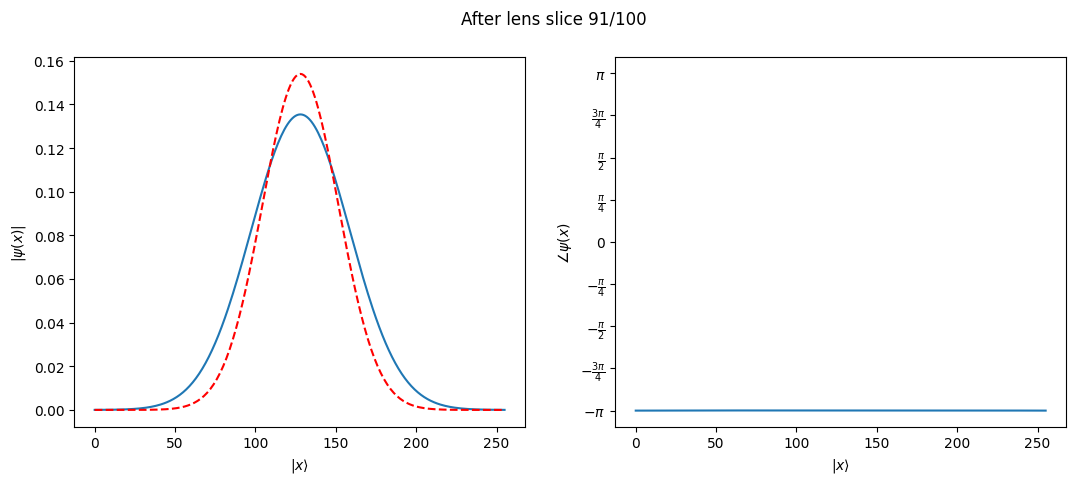

In [16]:
print("Plotting initial state")
plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
plt.suptitle("Initial state")
plt.show()

NUM_OF_LENS_SLICES_TO_PLOT = 5
NUM_OF_AFTER_LENS_SLICES_TO_PLOT = 5

for i, statevector in enumerate(lens_statevectors):
    if statevector is None:
        continue
    if (
        total_lenses_simulated > NUM_OF_LENS_SLICES_TO_PLOT
        and i % (total_lenses_simulated // NUM_OF_LENS_SLICES_TO_PLOT) != 0
    ):
        continue

    print(f"Plotting lens slice {i + 1}/{lens_slices}")

    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    z = lens_slice_thickness * (i + 1)
    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist, z, focal_length, vacuum_wavelength, refractive_index
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(np.abs(signal.normalized_data), "r--", label="thin lens analytical")

    plt.suptitle(f"After lens slice {i + 1}/{lens_slices}")
    plt.show()

for i, statevector in enumerate(after_lens_statevectors):
    if statevector is None:
        continue
    if i % (num_of_steps_after_lens // NUM_OF_AFTER_LENS_SLICES_TO_PLOT) != 0:
        continue

    print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    z = step_size_after_lens * (i + 1) + lens_thickness
    R_z, w_z = free_space_propagated_gaussian_wavefront(
        gaussian_beam_waist, z, vacuum_wavelength, refractive_index=1.0
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(np.abs(signal.normalized_data), "y--", label="free space analytical")

    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist,
        z,
        focal_length,
        vacuum_wavelength,
        refractive_index,
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(np.abs(signal.normalized_data), "r--", label="thin lens analytical")

    plt.suptitle(f"After free space step {i + 1}/{num_of_steps_after_lens}")
    plt.show()